1.Setting up the environment and uploading data set for further analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
df=pd.read_csv("F:\Data science pdf\PYTHON\landmines1.csv")
df["S"] = df["S"].replace({1: "Dry and sandy",2:"Dry and Humus",3:"Dry and Limy",4:"Humid and Sandy",5:"Humid and Humus",6:"Humid and Limy"})
df= df.rename(columns={
    'V': 'Voltage',      
    'H': 'Height',        
    'S': 'Soil_Type',   
    'M': 'Mine_Type'   
})
df.head(20)

,Voltage,Height,Soil_Type,Mine_Type
0,0.338157,0.000000,Dry and sandy,1
1,0.320241,0.181818,Dry and sandy,1
2,0.287009,0.272727,Dry and sandy,1
3,0.256284,0.454545,Dry and sandy,1
4,0.262840,0.545455,Dry and sandy,1
5,0.240966,0.727273,Dry and sandy,1
6,0.254410,0.818182,Dry and sandy,1
7,0.234924,1.000000,Dry and sandy,1
8,0.353474,0.000000,Humid and Sandy,1
9,0.335347,0.181818,Humid and Sandy,1


2.To know the count,mean,standard deviation and data type of the attributes

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Voltage    338 non-null    float64
 1   Height     338 non-null    float64
 2   Soil_Type  338 non-null    object 
 3   Mine_Type  338 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 10.7+ KB


,Voltage,Height,Mine_Type
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,2.952663
std,0.195819,0.306043,1.419703
min,0.197734,0.000000,1.000000
25%,0.309737,0.272727,2.000000
50%,0.359516,0.545455,3.000000
75%,0.482628,0.727273,4.000000
max,0.999999,1.000000,5.000000


3.To find the mean,median,mode, standard deviation and variance for the numerical attributes

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
df=pd.read_csv("F:\Data science pdf\PYTHON\landmines1.csv")
cols = df.select_dtypes(include=['number']).columns

print("mean:", df[cols].mean())
print("\nmedian:",  df[cols].median())
print("\nmode:", df[cols].mode().iloc[0])
print("\nStandard deviation:", df[cols].std())
print("\nVariance:", df[cols].var())

mean: Voltage      0.430634
Height       0.508876
Mine_Type    2.952663
dtype: float64

median: Voltage      0.359516
Height       0.545455
Mine_Type    3.000000
dtype: float64

mode: Voltage      0.999999
Height       0.181818
Mine_Type    1.000000
Name: 0, dtype: float64

Standard deviation: Voltage      0.195819
Height       0.306043
Mine_Type    1.419703
dtype: float64

Variance: Voltage      0.038345
Height       0.093663
Mine_Type    2.015557
dtype: float64


4. To visualize Mine Type Distribution with Histograms

1


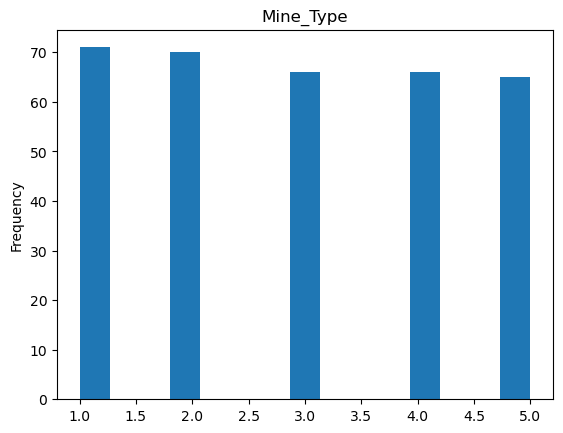

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
df['Mine_Type'].plot(kind='hist', bins=15, title='Mine_Type')
high_freq_mine = df['Mine_Type'].value_counts().idxmax()
print(high_freq_mine)

5. To Identify the Dominant Soil Type in Landmine dataset

Soil_Type
Dry and Humus      51
Dry and Limy       56
Dry and sandy      59
Humid and Humus    58
Humid and Limy     57
Humid and Sandy    57
dtype: int64


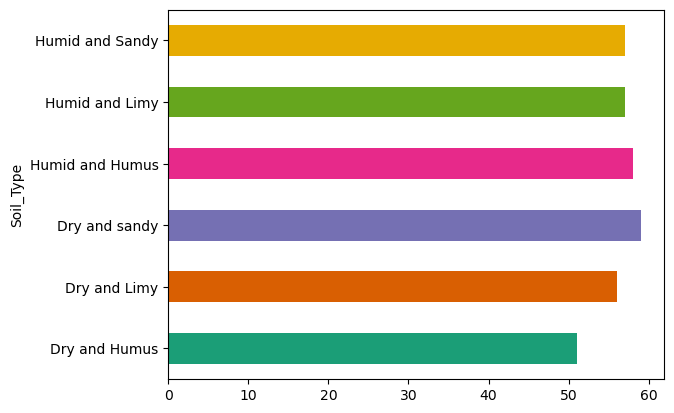

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
df=pd.read_csv('landmines1.csv')

df.groupby('Soil_Type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
soil_counts = df.groupby('Soil_Type').size()
print(soil_counts)


6. Assessing the Difference in Voltage and Height using       T-test

In [23]:
import pandas as pd
from scipy import stats
import numpy as np

t_test, p_value = stats.ttest_ind(df['Voltage'], df['Height'])

dof = len(df['Voltage']) + len(df['Height']) - 2
alpha = 0.05
table_value = 1.984  

if abs(t_test) > table_value:
    print("Reject the null hypothesis")
    print("There is a statistically significant difference between Voltage and Height.")
else:
    print("Accept the null hypothesis")
    print("There is no statistically significant difference between Voltage and Height.")

print("T-statistic:", t_test)
print("P-value:", p_value)
print("Critical value:", table_value)

Reject the null hypothesis
There is a statistically significant difference between Voltage and Height.
T-statistic: -3.9590941031112994
P-value: 8.322975205187554e-05
Critical value: 1.984


7.Performing Oneway F-test for Mine type and Height

In [24]:
import pandas as pd
from scipy import stats
import numpy as np

f_test, p_value = stats.f_oneway(df['Mine_Type'], df['Height'])
dfn = len(df['Mine_Type']) - 1
dfd = len(df['Height']) - 1

alpha = 0.05
table_value = 2.35

if f_test > table_value:
    print("Reject the null hypothesis")
    print("There is a statistically significant difference between the variances of Voltage and Height.")
else:
    print("Accept reject the null hypothesis")
    print("There is no statistically significant difference between the variances of Voltage and Height.")

print("F-statistic:", f_test)
print("P-value:", p_value)
print("Critical value:", table_value)

Reject the null hypothesis
There is a statistically significant difference between the variances of Voltage and Height.
F-statistic: 957.0214441230607
P-value: 1.829122246557091e-131
Critical value: 2.35


8.Visualizing the Relationship between Height and Mine Type

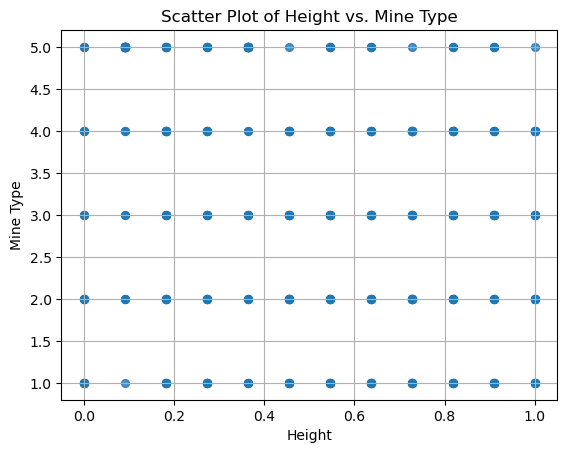

In [25]:
import matplotlib.pyplot as plt
df.plot(kind='scatter', x='Height', y='Mine_Type', s=32, alpha=.8)
plt.title('Scatter Plot of Height vs. Mine Type')
plt.xlabel('Height')
plt.ylabel('Mine Type')
plt.grid(True)
plt.show()


9.To calculate Correlation coefficient between Height and Mine type

In [27]:
import pandas as pd

correlation = df['Height'].corr(df['Mine_Type'])
print("Correlation between Height and Mine_Type:", correlation)

Correlation between Height and Mine_Type: -0.14493331000648887


10.To Predict Mine Type using Linear Regression with Height as Predictor  

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df[['Height']]  
y = df['Mine_Type'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R-squared:", r2) 


Coefficients: [-0.96025492]
Intercept: 3.472806781954319
Mean Squared Error: 1.8655396249561118
R-squared: -0.10253773335852001


11. To find the highest frequency of Voltage using Histogram

Voltage range: 0.20 - 0.24, Frequency: 14
Voltage range: 0.24 - 0.28, Frequency: 31
Voltage range: 0.28 - 0.32, Frequency: 55
Voltage range: 0.32 - 0.36, Frequency: 68
Voltage range: 0.36 - 0.40, Frequency: 39
Voltage range: 0.40 - 0.44, Frequency: 23
Voltage range: 0.44 - 0.48, Frequency: 20
Voltage range: 0.48 - 0.52, Frequency: 22
Voltage range: 0.52 - 0.56, Frequency: 11
Voltage range: 0.56 - 0.60, Frequency: 8
Voltage range: 0.60 - 0.64, Frequency: 6
Voltage range: 0.64 - 0.68, Frequency: 4
Voltage range: 0.68 - 0.72, Frequency: 3
Voltage range: 0.72 - 0.76, Frequency: 4
Voltage range: 0.76 - 0.80, Frequency: 2
Voltage range: 0.80 - 0.84, Frequency: 2
Voltage range: 0.84 - 0.88, Frequency: 2
Voltage range: 0.88 - 0.92, Frequency: 3
Voltage range: 0.92 - 0.96, Frequency: 1
Voltage range: 0.96 - 1.00, Frequency: 20


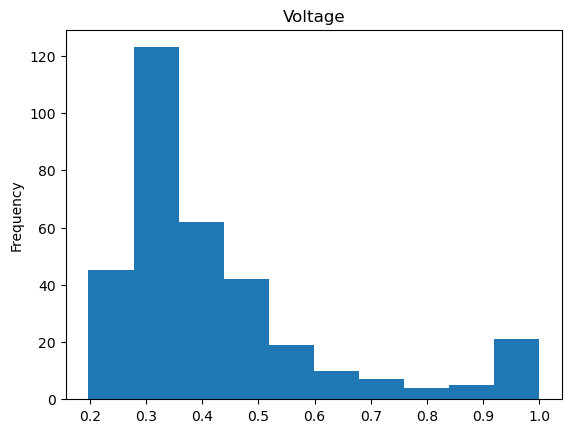

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
df=pd.read_csv('landmines1.csv')
df
df['Voltage'].plot(kind='hist', bins=10, title='Voltage')
import numpy as np
import matplotlib.pyplot as plt
voltage_values, bin_edges = np.histogram(df['Voltage'], bins=20)
for i in range(len(bin_edges) - 1):
    print(f"Voltage range: {bin_edges[i]:.2f} - {bin_edges[i + 1]:.2f}, Frequency: {voltage_values[i]}")

12. To find Inter Quartile Range for Mine_type

In [ ]:
data_column = 'Mine_Type'
Q1 = df[data_column].quantile(0.25)
Q3 = df[data_column].quantile(0.75)
IQR = Q3 - Q1
print("IQR range for Mine_Type is:",IQR)

IQR range for Mine_Type is: 2.0


13. To Predict Mine Type using Linear Regression with Height as Predictor

In [44]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df[['Height']]  
y = df['Mine_Type'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Coefficients: [-0.96025492]
Intercept: 3.472806781954319
Mean Squared Error: 1.8655396249561118
R-squared: -0.10253773335852001


14. 3D Scatter plot to visulaize the relationship between three variables: "Height","Voltage","Minetype"

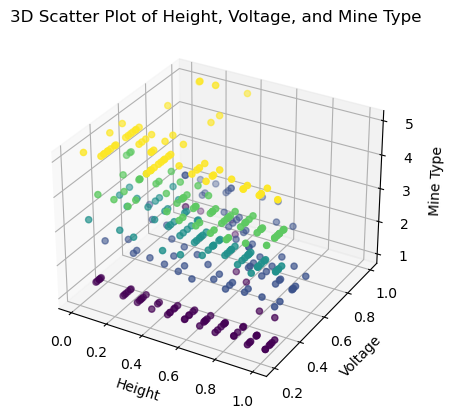

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Height'], df['Voltage'], df['Mine_Type'], c=df['Mine_Type'], cmap='viridis')
ax.set_title('3D Scatter Plot of Height, Voltage, and Mine Type')
ax.set_xlabel('Height')
ax.set_ylabel('Voltage')
ax.set_zlabel('Mine Type')
plt.show()

15.To visualize Heatmap of mean Voltage and Height 

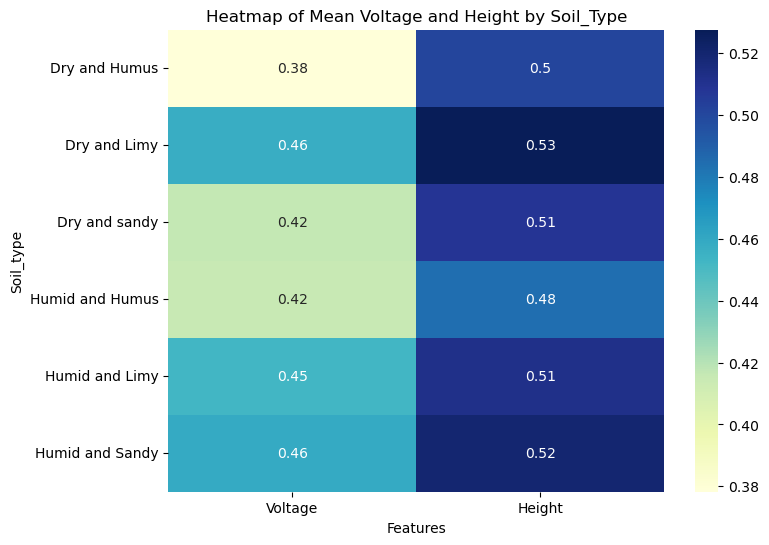

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("F:\Data science pdf\PYTHON\landmines1.csv")
gb = df.groupby("Soil_Type").agg({"Voltage": "mean", "Height": "mean"})
plt.figure(figsize=(8, 6))  
sns.heatmap(gb, annot=True, cmap="YlGnBu")  
plt.title("Heatmap of Mean Voltage and Height by Soil_Type")
plt.xlabel("Features")
plt.ylabel("Soil_type")
plt.show()

16.KNeighbourClassification of Landmines using Height and Voltage Data

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df[['Height', 'Voltage']]  
y = df['Mine_Type']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.38235294117647056


17.Analyzing the Relationship between Voltage and Height: Scatter Plot and Correlation

Correlation between Voltage and Height: -0.37752341070700407


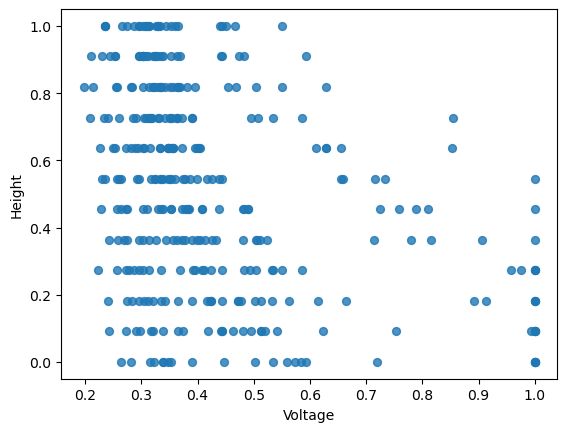

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
df=pd.read_csv('landmines1.csv')
df.plot(kind='scatter', x='Voltage', y='Height', s=32, alpha=.8)
correlation = df['Voltage'].corr(df['Height'])
print(f"Correlation between Voltage and Height: {correlation}")


18.Decision Tree Analysis for Landmine Detection

Accuracy: 0.96


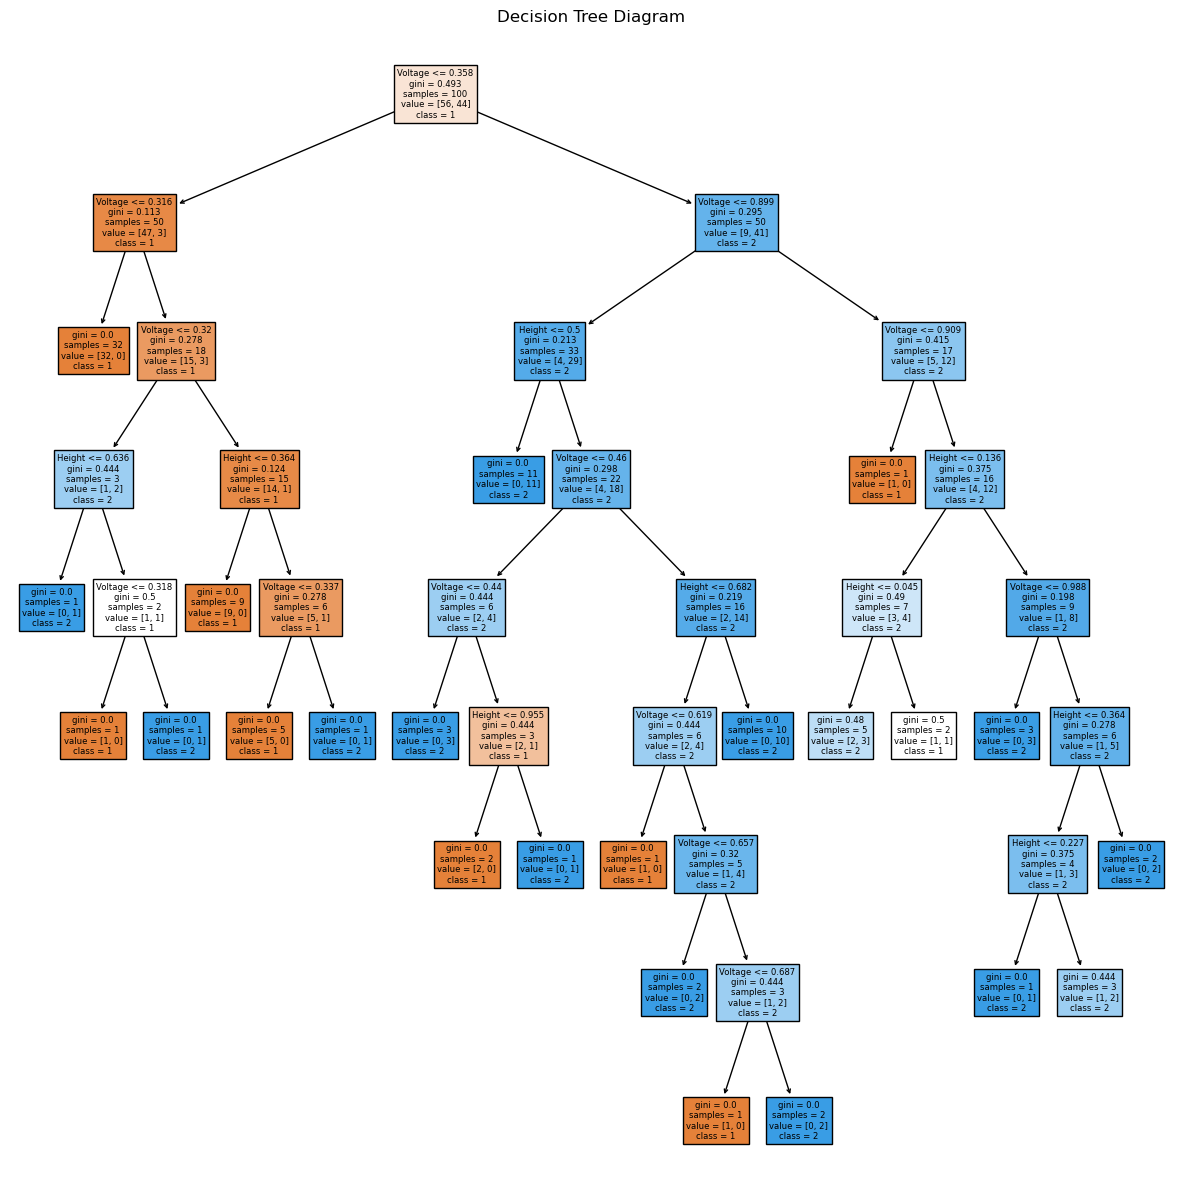

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df_subset = df.head(100)
X = df_subset[['Height', 'Voltage']] 
y = df_subset['Mine_Type']  
tree_classifier = DecisionTreeClassifier(random_state=42)  
tree_classifier.fit(X, y)
y_pred = tree_classifier.predict(X)
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)
plt.figure(figsize=(15,15))  
plot_tree(tree_classifier, feature_names=['Height', 'Voltage'], class_names=tree_classifier.classes_.astype(str), filled=True)
plt.title("Decision Tree Diagram")
plt.show()

19. To visualize the Column chart for soil type 

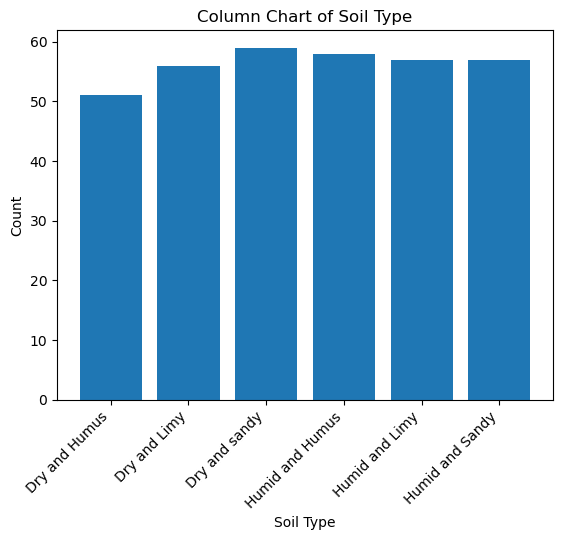

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
x_column = 'Soil_Type'
grouped_data = df.groupby(x_column).size().reset_index(name='Count')
plt.bar(grouped_data[x_column], grouped_data['Count'])
plt.title('Column Chart of Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

20."K-Nearest Neighbors (KNN) Classification for Mine Type Detection Using Height and Voltage"

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df[['Height', 'Voltage']] 
y = df['Mine_Type']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for i in range(2, 10):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, y_train)
    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)
    print("k is ", i)
    print('training accuracy is ', accuracy_score(train_predict, y_train))
    print('testing accuracy is ', accuracy_score(test_predict, y_test))

k is  2
training accuracy is  0.6555555555555556
testing accuracy is  0.3235294117647059
k is  3
training accuracy is  0.6111111111111112
testing accuracy is  0.35294117647058826
k is  4
training accuracy is  0.5740740740740741
testing accuracy is  0.38235294117647056
k is  5
training accuracy is  0.562962962962963
testing accuracy is  0.38235294117647056
k is  6
training accuracy is  0.5740740740740741
testing accuracy is  0.38235294117647056
k is  7
training accuracy is  0.5481481481481482
testing accuracy is  0.38235294117647056
k is  8
training accuracy is  0.5592592592592592
testing accuracy is  0.39705882352941174
k is  9
training accuracy is  0.5148148148148148
testing accuracy is  0.36764705882352944


21.Random Forest Classification for Mine Type Detection Using Height and Voltage

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['Height', 'Voltage']]  
y = df['Mine_Type']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)  
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.3235294117647059


22.Pie Chart Representation of Soil Type Distribution

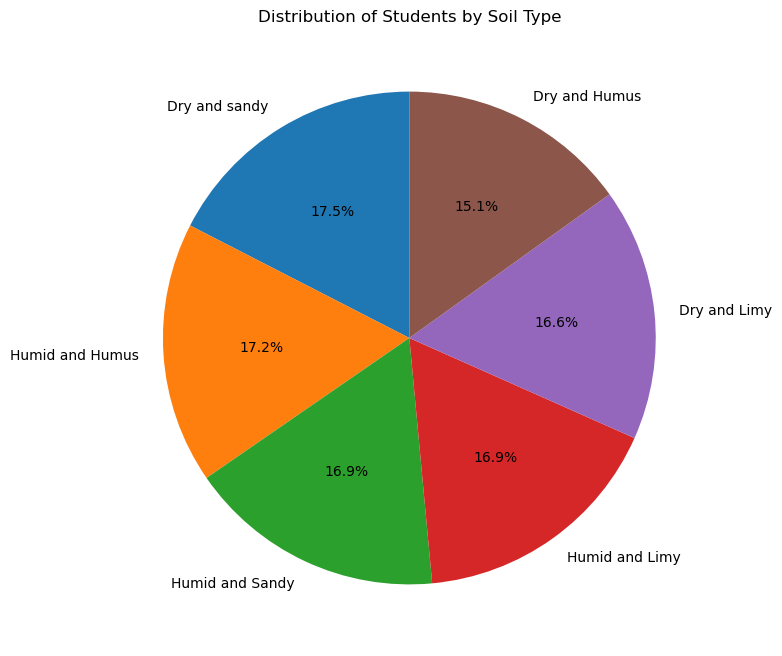

In [11]:
a = df['Soil_Type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(a, labels=a.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Students by Soil Type')
plt.show()

23.Principal Component Analysis (PCA) of Landmines Dataset Using Height and Voltage

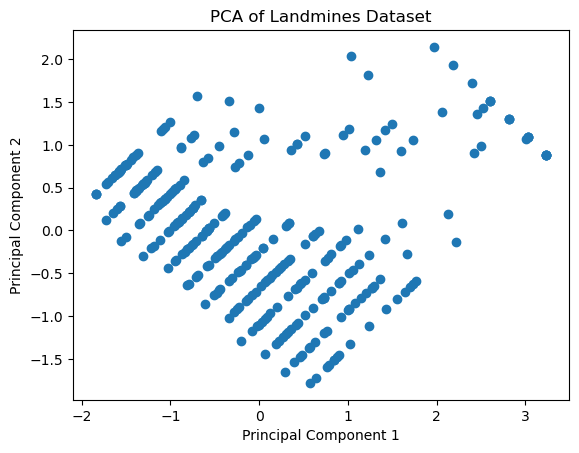

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('landmines1.csv')
X = df[['Height', 'Voltage']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
import matplotlib.pyplot as plt
plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Landmines Dataset')
plt.show()

24.Line Plot of Mine Type vs. Soil Type Distribution

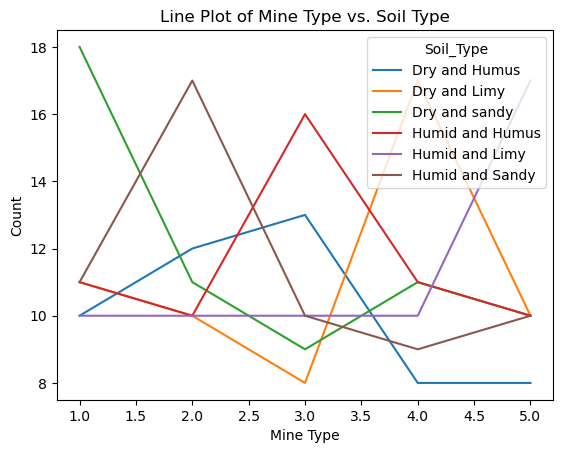

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

grouped_data = df.groupby(['Mine_Type', 'Soil_Type'])['Soil_Type'].count().reset_index(name='Count')
sns.lineplot(x='Mine_Type', y='Count', hue='Soil_Type', data=grouped_data)
plt.title('Line Plot of Mine Type vs. Soil Type')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.show()

25.Support Vector Machine (SVM) Classification for Mine Type Detection Using Height and Voltage

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X = df[['Height', 'Voltage']]  
y = df['Mine_Type']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_classifier = SVC(kernel='linear')  
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.22058823529411764
